# 00

In [1]:
import os
PROJECT_ROOT = "/home/dotamthuc-3090/Projects/ViewSynthesis/"
print("PROJECT_ROOT:", PROJECT_ROOT)

import sys
lib_decompre = "/home/dotamthuc-3090/Projects/ViewSynthesis/Differentiable3DPC-Decompression-and-Rendering"
sys.path.insert(0, lib_decompre)

lib_svraster = "/home/dotamthuc-3090/Projects/ViewSynthesis/svraster"
sys.path.insert(0, lib_svraster)

import itertools
import numpy as np
import torch
from matplotlib.pylab import plt

from libs.dataloader.View import View, ViewCreator
from libs.dataloader.Scene import Scene

import decompress_render

from src.dataloader.data_pack import DataPack
from src.sparse_voxel_model import SparseVoxelModel
from src.config import cfg, update_argparser, update_config

PROJECT_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/


In [2]:
source_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/"
scene_dataset = Scene(
    source_path, image_dir_name="images",
    res_downscale=3.5, res_width=0,
    test_every=-1
)

train_views = scene_dataset.get_train_views()
test_views = scene_dataset.get_test_views()
len(train_views), len(test_views)

Read dataset in COLMAP format.


(279, 0)

In [3]:
# Init voxel model
voxel_model = SparseVoxelModel(
    n_samp_per_vox=3,
    sh_degree=0,
    ss=1.5,
    white_background=True,
    black_background=False,
)
voxel_model.load_iteration("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03", 95000)
voxel_model.freeze_vox_geo()

morton_code_tensor = voxel_model.vox_morton_code.clone().detach()
vox_roots_tensor = voxel_model.vox_root.clone().detach()
vox_length_tensor = voxel_model.vox_size.clone().detach()
vox2corners_tensor = voxel_model.vox_key.clone().detach()
vox_params_geo_tensor = voxel_model.vox_conners_geo_params.clone().detach()
vox_params_color_tensor = voxel_model.vox_static_rgbs.clone().detach()

print(f"morton_code_tensor={morton_code_tensor.shape, morton_code_tensor.dtype}")
print(f"vox_roots_tensor={vox_roots_tensor.shape, vox_roots_tensor.dtype}")
print(f"vox_length_tensor={vox_length_tensor.shape, vox_length_tensor.dtype}")
print(f"vox2corners_tensor={vox2corners_tensor.shape, vox2corners_tensor.dtype}")
print(f"vox_params_geo_tensor={vox_params_geo_tensor.shape, vox_params_geo_tensor.dtype}")
print(f"vox_params_color_tensor={vox_params_color_tensor.shape, vox_params_color_tensor.dtype}")

morton_code_tensor=(torch.Size([9749024, 1]), torch.int64)
vox_roots_tensor=(torch.Size([9749024, 3]), torch.float32)
vox_length_tensor=(torch.Size([9749024, 1]), torch.float32)
vox2corners_tensor=(torch.Size([9749024, 8]), torch.int64)
vox_params_geo_tensor=(torch.Size([16611122, 1]), torch.float32)
vox_params_color_tensor=(torch.Size([9749024, 3]), torch.float32)


In [4]:
a_view = train_views[0]
ss = 1.0

w_src, h_src = a_view.render_width, a_view.render_height
w, h = round(w_src * ss), round(h_src * ss)
w_ss, h_ss = w / w_src, h / h_src

camera_settings = decompress_render.renderer.CameraSettings(
    image_width=w, 
    image_height=h, 
    tanfovx=a_view.tanfovx, 
    tanfovy=a_view.tanfovy, 
    cx=a_view.cx * w_ss,
    cy=a_view.cy * h_ss,
    w2c_matrix=a_view.world2view.cuda(),
    c2w_matrix=a_view.view2world.cuda()
)

render_settings = decompress_render.renderer.RenderSettings(
    num_sample_per_vox=3,
    bg_color=float(voxel_model.white_background),
    near=a_view.near,
    need_depth=True,
    track_max_w=False,
    debug=True,
)


N: 9749024 


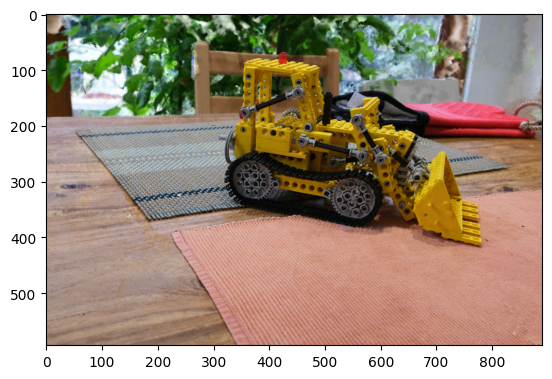

In [5]:
result_rendered = decompress_render.renderer.rasterize_voxels_main(
    camera_settings=camera_settings,
    render_settings=render_settings,
    morton_code=morton_code_tensor,
    vox_roots=vox_roots_tensor,
    vox_length=vox_length_tensor,
    vox2corners=vox2corners_tensor,
    vox_params_geo=vox_params_geo_tensor,
    vox_params_color=vox_params_color_tensor,
)

img_out = torch.permute(result_rendered[0].clamp(0, 1), dims=(1, 2, 0)).detach().cpu().numpy()
plt.imshow(img_out)

# 01

In [1]:
import os
PROJECT_ROOT = "/home/dotamthuc-3090/Projects/ViewSynthesis/"
print("PROJECT_ROOT:", PROJECT_ROOT)

import sys
lib_decompre = "/home/dotamthuc-3090/Projects/ViewSynthesis/Differentiable3DPC-Decompression-and-Rendering"
sys.path.insert(0, lib_decompre)

lib_svraster = "/home/dotamthuc-3090/Projects/ViewSynthesis/svraster"
sys.path.insert(0, lib_svraster)

import itertools
import numpy as np
import torch
from matplotlib.pylab import plt

from libs.dataloader.View import View, ViewCreator
from libs.dataloader.Scene import Scene

import decompress_render

from src.dataloader.data_pack import DataPack
from src.sparse_voxel_model import SparseVoxelModel
from src.config import cfg, update_argparser, update_config

PROJECT_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/


In [ ]:
def load_geometry_from_sparse_voxels_model(sourse_path):
    voxel_model_frame = SparseVoxelModel(
        n_samp_per_vox=1,
        sh_degree=0,
        ss=1.0,
        white_background=False,
        black_background=True,
    )
    voxel_model_frame.load(sourse_path)

    geometry_info = {}
    geometry_info["morton_code_tensor"] = voxel_model_frame.vox_morton_code.clone().detach()
    geometry_info["vox_roots_tensor"] = voxel_model_frame.vox_root.clone().detach()
    geometry_info["vox_length_tensor"] = voxel_model_frame.vox_size.clone().detach()
    geometry_info["vox2corners_tensor"] = voxel_model_frame.vox_key.clone().detach()
    geometry_info["vox_params_geo_tensor"] = voxel_model_frame.vox_conners_geo_params.clone().detach()
    geometry_info["vox_params_color_tensor"] = voxel_model_frame.vox_static_rgbs.clone().detach()

    del voxel_model_frame
    torch.cuda.empty_cache()

    return geometry_info


class DensityField:
    def __init__(
        self,
        source_path,
        num_sample_per_voxel=1
    ):
        # CONFIG INFO
        self.num_sample_per_voxel = num_sample_per_voxel

        geometry_info = load_geometry_from_sparse_voxels_model(source_path)
        #### Define the Density Field
        self.voxel_morton_code = geometry_info["morton_code_tensor"]
        self.voxel_position    = geometry_info["vox_roots_tensor"]
        self.voxel_size        = geometry_info["vox_length_tensor"]
        self.voxel2corner      = geometry_info["vox2corners_tensor"]
        self.corner_geo_params = geometry_info["vox_params_geo_tensor"]
        self.num_voxels        = self.voxel_morton_code.shape[0]

        #### Define current Attribute Field
        self.voxel_attribute_field = geometry_info["vox_params_color_tensor"]

    
    def apply_phi(self, view_info):

        w, h = view_info.render_width, view_info.render_height

        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=view_info.render_width, 
            image_height=view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx,
            cy=view_info.cy,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, _, _, _ = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=self.voxel_attribute_field,
        )

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0)).detach()

        return rendered_image


    def apply_phi_with_F(self, voxel_attribute, view_info):

        if voxel_attribute.shape != (self.num_voxels, 3):
            raise Exception(f"Expect voxel_attribute in is static voxels color ({self.num_voxels}, 3) but got", voxel_attribute.shape)

        w, h = view_info.render_width, view_info.render_height
        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=view_info.render_width, 
            image_height=view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx,
            cy=view_info.cy,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, _, _, _ = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=voxel_attribute, # use as input voxel_attribute 
        )

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0))

        return rendered_image

def apply_A_transpose(
        lowres_denfield: DensityField,
        highres_denfield: DensityField,
        scene: Scene,
        optim_opt: dict
    ):

    MSE_calculator = torch.nn.MSELoss()

    approx_attribute_field = torch.nn.Parameter(torch.full(
        [highres_denfield.num_voxels, 3], 0.5, 
        dtype=torch.float32, device="cuda"
    ))
    optimizer = torch.optim.Adam([approx_attribute_field], lr=optim_opt.get("lr", 0.001))
    train_views = scene.get_train_views()

    i=0
    for loop in range(optim_opt.get("num_scene_loop", 30)):
        for view in train_views:
            ##
            optimizer.zero_grad()
            true_low_res_img   = lowres_denfield.apply_phi(view)
            approx_low_res_img = highres_denfield.apply_phi_with_F(approx_attribute_field, view)
            ###
            mse_val = MSE_calculator(approx_low_res_img, true_low_res_img)
            mse_val.backward()
            ###
            print(f"loop = {loop} iter = {i} psnr={-10 * np.log10(mse_val.detach().cpu())}")
            optimizer.step()
            i+=1

    output = approx_attribute_field.detach()
    
    # Cleaning
    optimizer.zero_grad()
    del optimizer
    torch.cuda.empty_cache()

    return output

In [3]:
source_path = "/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/"
scene_dataset = Scene(
    source_path, image_dir_name="images",
    res_downscale=3.5, res_width=0,
    test_every=-1
)

train_views = scene_dataset.get_train_views()
test_views = scene_dataset.get_test_views()
len(train_views), len(test_views)

Read dataset in COLMAP format.


(279, 0)

In [8]:
high_res = DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/checkpoints/iter045999_model.pt")
low_res = DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v03/checkpoints/iter013999_model.pt")

approx_attribute_field = apply_A_transpose(
    low_res,
    high_res,
    scene_dataset,
    optim_opt={
        "lr": 0.001,
        "num_scene_loop": 30
    }
)


loop = 0 iter = 0 loss_values=13.129465103149414
loop = 0 iter = 1 loss_values=13.043323516845703
loop = 0 iter = 2 loss_values=12.98413372039795
loop = 0 iter = 3 loss_values=13.058042526245117
loop = 0 iter = 4 loss_values=13.03803539276123
loop = 0 iter = 5 loss_values=13.064242362976074
loop = 0 iter = 6 loss_values=12.970726013183594
loop = 0 iter = 7 loss_values=12.96388053894043
loop = 0 iter = 8 loss_values=12.91481876373291
loop = 0 iter = 9 loss_values=12.980405807495117
loop = 0 iter = 10 loss_values=12.952509880065918
loop = 0 iter = 11 loss_values=13.026165962219238
loop = 0 iter = 12 loss_values=13.09043025970459
loop = 0 iter = 13 loss_values=13.235773086547852
loop = 0 iter = 14 loss_values=13.337555885314941
loop = 0 iter = 15 loss_values=13.406850814819336
loop = 0 iter = 16 loss_values=13.416099548339844
loop = 0 iter = 17 loss_values=13.5077486038208
loop = 0 iter = 18 loss_values=13.71335506439209
loop = 0 iter = 19 loss_values=13.795684814453125
loop = 0 iter = 20

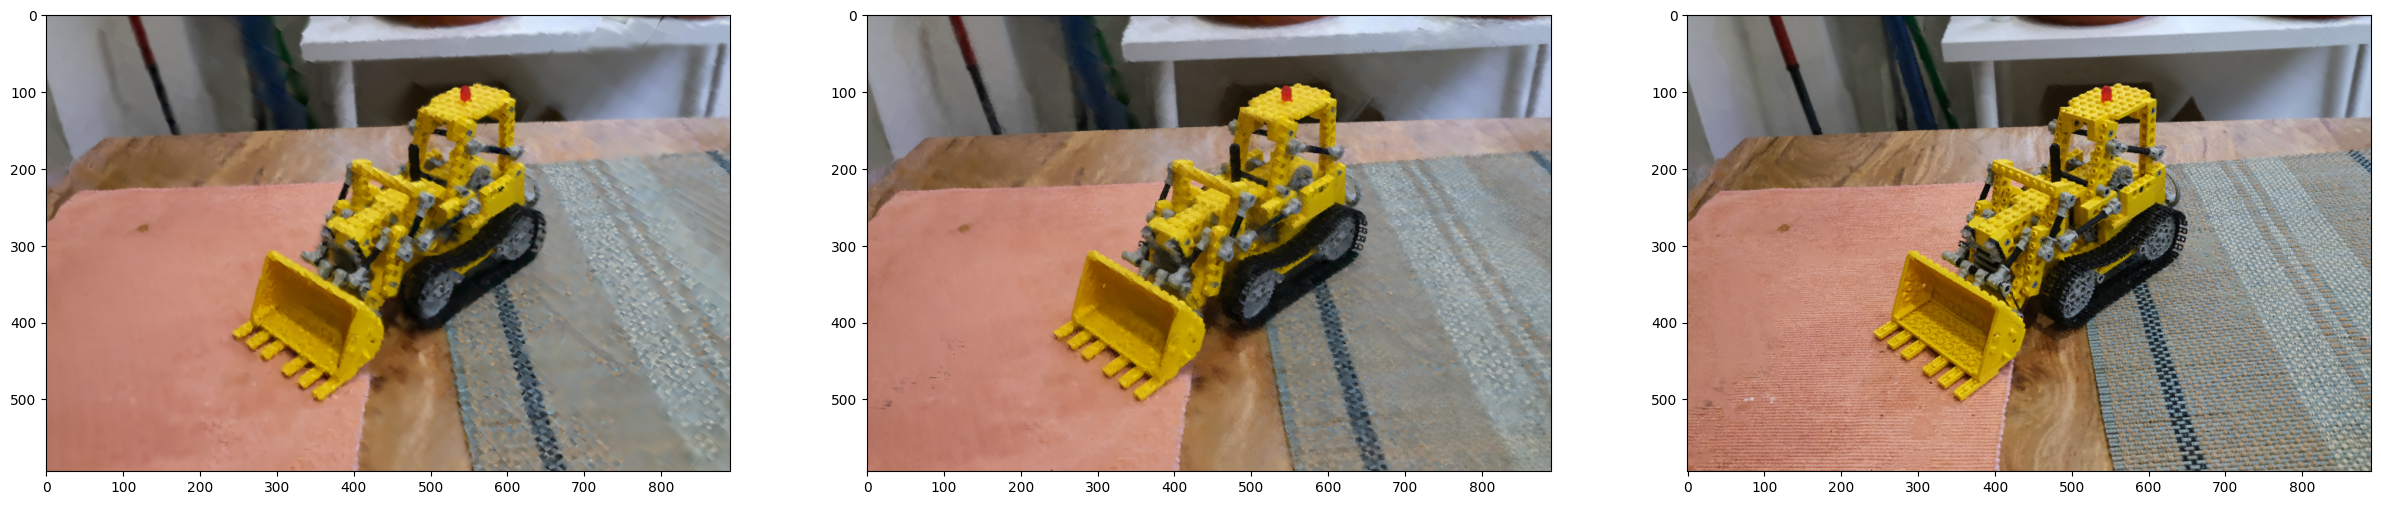

In [11]:
rendered_img_low = low_res.apply_phi(train_views[100]).cpu().numpy()
rendered_img_high = high_res.apply_phi(train_views[100]).cpu().numpy()
rendered_img_low_approx = high_res.apply_phi_with_F(approx_attribute_field, train_views[100]).detach().cpu().numpy()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))
ax[0].imshow(rendered_img_low)
ax[1].imshow(rendered_img_low_approx)
ax[2].imshow(rendered_img_high)

# err = np.clip(np.abs(rendered_img_low_approx-rendered_img_low) / rendered_img_low_approx, 0.0, 1.0)
# ax[3].imshow(err)

plt.show()